Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,f1_score)


Data Collection and Processing

In [ ]:
# loading the dataset to pandas Dataframe
loan_dataset=pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')

In [ ]:
type(loan_dataset)

pandas.core.frame.DataFrame

In [ ]:
# printing the first 5 rows of the dataset
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# no. of rows n columns
loan_dataset.shape


(614, 13)

In [ ]:
# Basic info and types
loan_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# statistical measures
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# Number of missing values in each column (BEFORE handling)

print(loan_dataset.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [ ]:
# Identify numerical and categorical columns
numerical_cols = loan_dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = loan_dataset.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# Impute numerical columns with median (robust to outliers)
imputer_num = SimpleImputer(strategy='median')
loan_dataset[numerical_cols] = imputer_num.fit_transform(loan_dataset[numerical_cols])

# Impute categorical columns with mode (most frequent value)
imputer_cat = SimpleImputer(strategy='most_frequent')
loan_dataset[categorical_cols] = imputer_cat.fit_transform(loan_dataset[categorical_cols])

# Verify no missing values remain
print(loan_dataset.isnull().sum())


Numerical columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


Data Cleaning and Label Encoding

In [ ]:
loan_dataset['Dependents'] = loan_dataset['Dependents'].astype(str)
loan_dataset['Dependents'] = loan_dataset['Dependents'].replace('3+', '4')
loan_dataset['Dependents'] = loan_dataset['Dependents'].astype(int)
print(loan_dataset['Dependents'].value_counts())

Dependents
0    360
1    102
2    101
4     51
Name: count, dtype: int64


In [ ]:
# label encoding
loan_dataset.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)

In [ ]:
# printing the first 5 rows of the dataset
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1


In [ ]:
# Use LabelEncoder for categorical columns
categorical_cols_to_encode = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
label_encoders = {}

for col in categorical_cols_to_encode:
    le = LabelEncoder()
    loan_dataset[col] = le.fit_transform(loan_dataset[col].astype(str))
    label_encoders[col] = le
    print(f"\n{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

loan_dataset.head()


Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Married encoding: {'No': np.int64(0), 'Yes': np.int64(1)}

Education encoding: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}

Self_Employed encoding: {'No': np.int64(0), 'Yes': np.int64(1)}

Property_Area encoding: {'Rural': np.int64(0), 'Semiurban': np.int64(1), 'Urban': np.int64(2)}


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


Feature Engineering

In [ ]:
print("\nOriginal features:", list(loan_dataset.columns))

# Create derived features
loan_dataset['Total_Income'] = loan_dataset['ApplicantIncome'] + loan_dataset['CoapplicantIncome']
loan_dataset['Debt_to_Income'] = loan_dataset['LoanAmount'] / (loan_dataset['Total_Income'] + 1)
loan_dataset['LTV_Ratio'] = loan_dataset['LoanAmount'] / (loan_dataset['ApplicantIncome'] + 1)
loan_dataset['CoApplicant_Ratio'] = loan_dataset['CoapplicantIncome'] / (loan_dataset['ApplicantIncome'] + 1)
loan_dataset['Income_Log'] = np.log1p(loan_dataset['ApplicantIncome'])
loan_dataset['Credit_Debt_Interaction'] = loan_dataset['Credit_History'] * loan_dataset['Debt_to_Income']

print("New features added. Total columns now:", list(loan_dataset.columns))



Original features: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
New features added. Total columns now: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'Total_Income', 'Debt_to_Income', 'LTV_Ratio', 'CoApplicant_Ratio', 'Income_Log', 'Credit_Debt_Interaction']


Data Visualisation

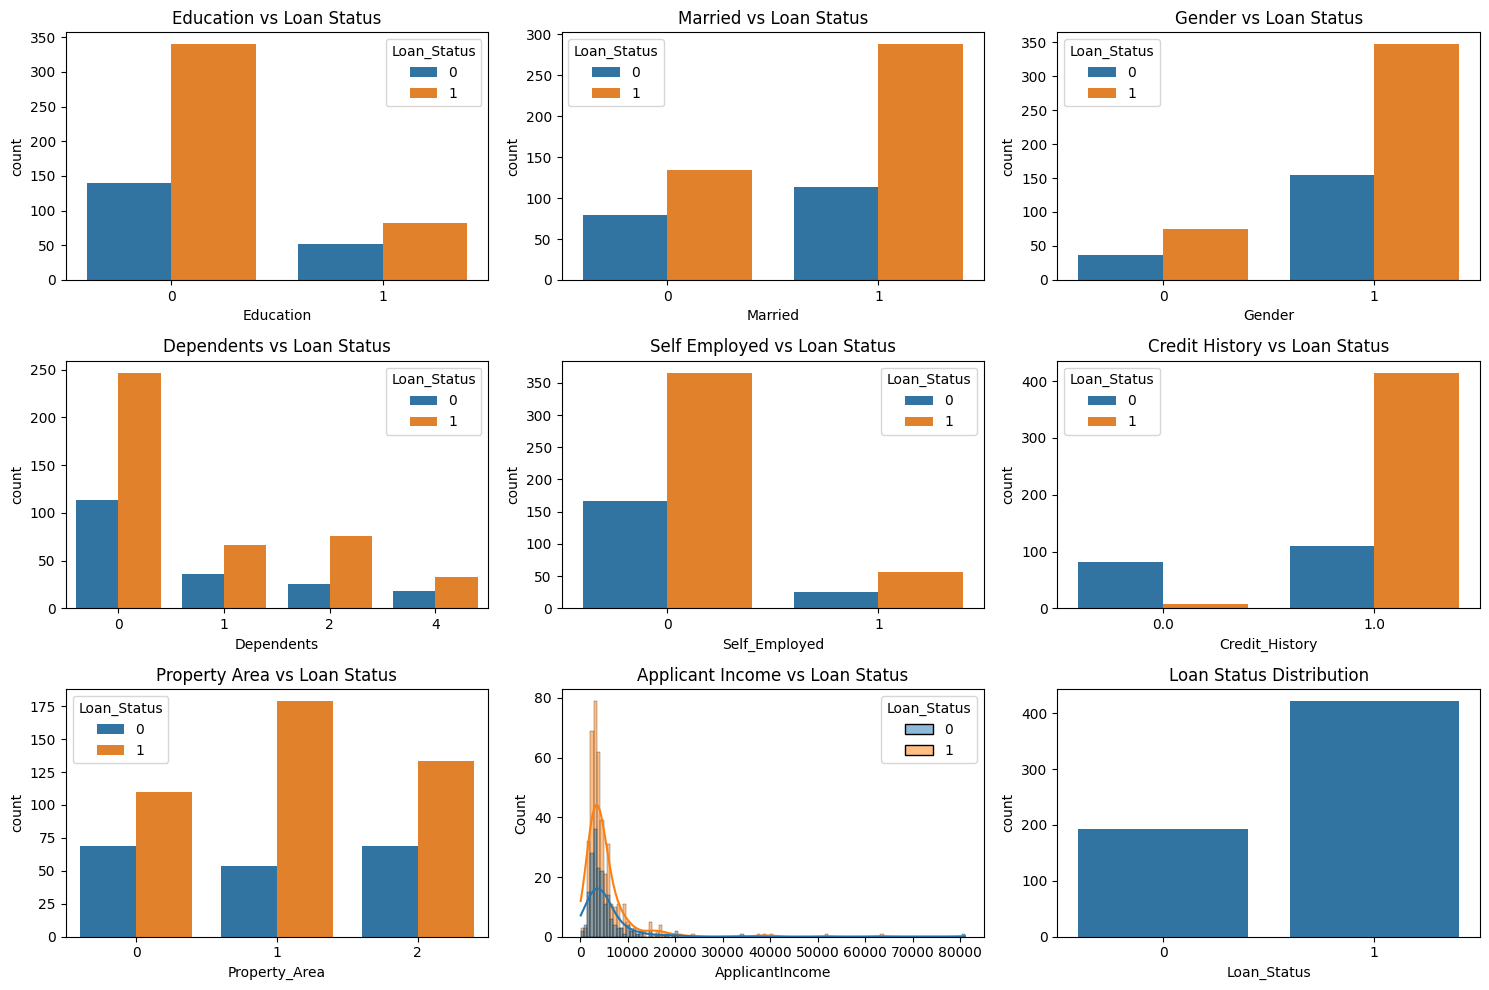

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 3, 1)
sns.countplot(x='Education', hue='Loan_Status', data=loan_dataset)
plt.title('Education vs Loan Status')

plt.subplot(3, 3, 2)
sns.countplot(x='Married', hue='Loan_Status', data=loan_dataset)
plt.title('Married vs Loan Status')

plt.subplot(3, 3, 3)
sns.countplot(x='Gender', hue='Loan_Status', data=loan_dataset)
plt.title('Gender vs Loan Status')

plt.subplot(3, 3, 4)
sns.countplot(x='Dependents', hue='Loan_Status', data=loan_dataset)
plt.title('Dependents vs Loan Status')

plt.subplot(3, 3, 5)
sns.countplot(x='Self_Employed', hue='Loan_Status', data=loan_dataset)
plt.title('Self Employed vs Loan Status')

plt.subplot(3, 3, 6)
sns.countplot(x='Credit_History', hue='Loan_Status', data=loan_dataset)
plt.title('Credit History vs Loan Status')

plt.subplot(3, 3, 7)
sns.countplot(x='Property_Area', hue='Loan_Status', data=loan_dataset)
plt.title('Property Area vs Loan Status')

plt.subplot(3, 3, 8)
sns.histplot(data=loan_dataset, x='ApplicantIncome', hue='Loan_Status', kde=True)
plt.title('Applicant Income vs Loan Status')

plt.subplot(3, 3, 9)
sns.countplot(x='Loan_Status', data=loan_dataset)
plt.title('Loan Status Distribution')

plt.tight_layout()
plt.show()


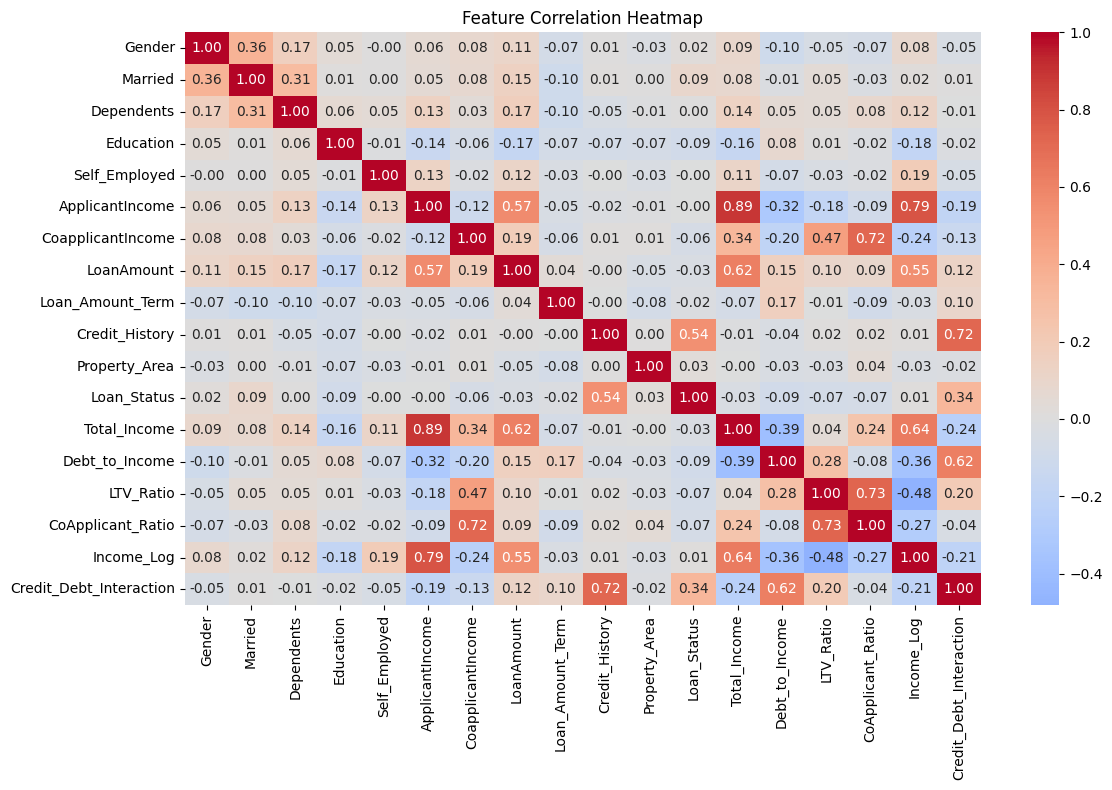

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
# Drop non-numeric column - Loan_ID
correlation_matrix = loan_dataset.drop(columns=['Loan_ID']).corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


Separate Features and Target

In [ ]:
# Separate the data and target variable
X = loan_dataset.drop(columns=['Loan_ID', 'Loan_Status'], axis=1)
Y = loan_dataset['Loan_Status']

print("\nFeatures shape:", X.shape)
print("Target shape:", Y.shape)
print("\nLoan Status distribution:")
print(Y.value_counts())
print("\nLoan Status normalized:")
print(Y.value_counts(normalize=True))


Features shape: (614, 17)
Target shape: (614,)

Loan Status distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64

Loan Status normalized:
Loan_Status
1    0.687296
0    0.312704
Name: proportion, dtype: float64


Splitting the Data

In [ ]:
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.30,
                                                      stratify=Y, random_state=2)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5,
                                                 stratify=Y_temp, random_state=2)

In [ ]:
print(X.shape,X_train.shape,X_val.shape,X_test.shape)

(614, 17) (429, 17) (92, 17) (93, 17)


Training the Model

Support Vector Machine Model

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train shape: {X_train_scaled.shape}")

Scaled train shape: (429, 17)


Training Multiple Models

In [ ]:
print("TRAINING MULTIPLE MODELS")

# Model 1: Logistic Regression (baseline)
print("\n1. Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=2)
lr_model.fit(X_train_scaled, Y_train)
lr_val_pred = lr_model.predict(X_val_scaled)
lr_val_acc = accuracy_score(Y_val, lr_val_pred)
print(f"   Validation Accuracy: {lr_val_acc:.4f}")

# Model 2: Random Forest
print("\n2. Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=150,
                                   max_depth=10,
                                   min_samples_split=5,
                                   random_state=2, n_jobs=-1)
rf_model.fit(X_train_scaled, Y_train)
rf_val_pred = rf_model.predict(X_val_scaled)
rf_val_acc = accuracy_score(Y_val, rf_val_pred)
print(f"   Validation Accuracy: {rf_val_acc:.4f}")

# Model 3: SVM with GridSearchCV (hyperparameter tuning)
print("\n3. Training SVM with GridSearchCV...")
svm_params = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(svm.SVC(probability=True, random_state=2),
                        svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, Y_train)
print(f"   Best SVM parameters: {svm_grid.best_params_}")
svm_best = svm_grid.best_estimator_
svm_val_pred = svm_best.predict(X_val_scaled)
svm_val_acc = accuracy_score(Y_val, svm_val_pred)
print(f"   Validation Accuracy: {svm_val_acc:.4f}")

TRAINING MULTIPLE MODELS

1. Training Logistic Regression...
   Validation Accuracy: 0.7826

2. Training Random Forest...
   Validation Accuracy: 0.7935

3. Training SVM with GridSearchCV...
   Best SVM parameters: {'C': 1, 'kernel': 'linear'}
   Validation Accuracy: 0.7826


Selecting Best Model

In [ ]:
model_scores = {
    'Logistic Regression': lr_val_acc,
    'Random Forest': rf_val_acc,
    'SVM (with GridSearch)': svm_val_acc
}


print("MODEL COMPARISON (Validation Set)\n")

for model_name, score in model_scores.items():
    print(f"{model_name:.<40} {score:.4f}")

# Select best model
best_model_name = max(model_scores, key=model_scores.get)
if best_model_name == 'Logistic Regression':
    best_model = lr_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = svm_best

print(f"\nSELECTED BEST MODEL: {best_model_name}")

MODEL COMPARISON (Validation Set)

Logistic Regression..................... 0.7826
Random Forest........................... 0.7935
SVM (with GridSearch)................... 0.7826

SELECTED BEST MODEL: Random Forest


Model Evaluation

In [ ]:
print("FINAL TEST SET EVALUATION")

# Get predictions
X_test_prediction = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(X_test_prediction, Y_test)

# Get probabilities for ROC-AUC
if hasattr(best_model, 'predict_proba'):
    X_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    test_roc_auc = roc_auc_score(Y_test, X_test_proba)
else:
    X_test_proba = X_test_prediction
    test_roc_auc = np.nan

test_f1 = f1_score(Y_test, X_test_prediction)

train_accuracy = accuracy_score(best_model.predict(X_train_scaled), Y_train)
test_precision = precision_score(Y_test, X_test_prediction)
test_recall = recall_score(Y_test, X_test_prediction)

print(f'\nAccuracy on training data: {train_accuracy:.4f}')
print(f'Accuracy on test data: {test_accuracy:.4f}')
print(f'ROC-AUC Score: {test_roc_auc:.4f}')
print(f'F1-Score: {test_f1:.4f}')
print(f'Precision: {test_precision:.4f}')     # NEW
print(f'Recall: {test_recall:.4f}')           # NEW

print("\nClassification Report:")
print(classification_report(Y_test, X_test_prediction,
                          target_names=['Not Approved', 'Approved']))

FINAL TEST SET EVALUATION

Accuracy on training data: 1.0000
Accuracy on test data: 0.8065
ROC-AUC Score: 0.8475
F1-Score: 0.8594

Classification Report:
              precision    recall  f1-score   support

Not Approved       0.69      0.69      0.69        29
    Approved       0.86      0.86      0.86        64

    accuracy                           0.81        93
   macro avg       0.77      0.77      0.77        93
weighted avg       0.81      0.81      0.81        93



Visualisation- Confusion Matrix and ROC Curve


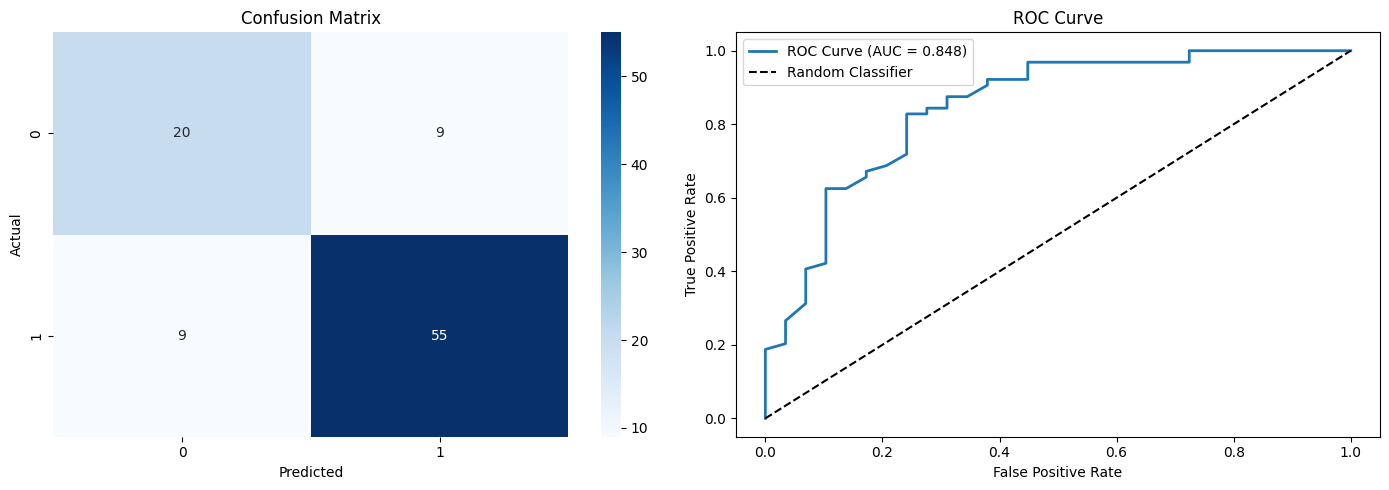

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
if not np.isnan(test_roc_auc):
    fpr, tpr, _ = roc_curve(Y_test, X_test_proba)
    axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {test_roc_auc:.3f})', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()

plt.tight_layout()
plt.show()

Feature Importance

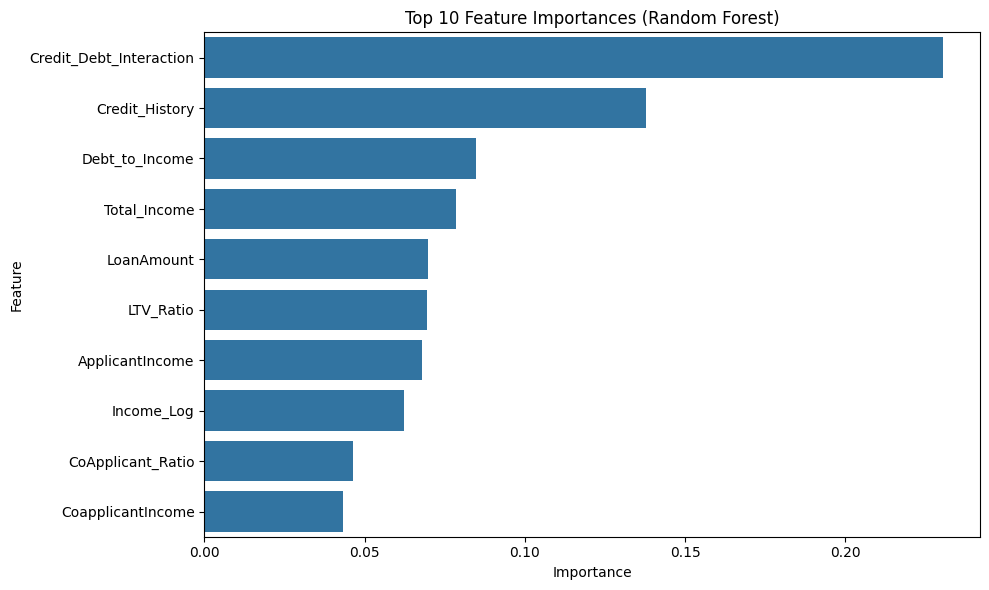


Top 10 Important Features:
                    Feature  Importance
16  Credit_Debt_Interaction    0.230514
9            Credit_History    0.137867
12           Debt_to_Income    0.084866
11             Total_Income    0.078443
7                LoanAmount    0.069739
13                LTV_Ratio    0.069645
5           ApplicantIncome    0.067928
15               Income_Log    0.062376
14        CoApplicant_Ratio    0.046340
6         CoapplicantIncome    0.043325


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
    plt.title(f'Top 10 Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Important Features:")
    print(feature_importance.head(10))

Save Model

In [ ]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("\nSaved files: model.pkl, scaler.pkl, label_encoders.pkl")


Saved files: model.pkl, scaler.pkl, label_encoders.pkl


Making a predictive system

In [ ]:

print("EXAMPLE PREDICTION")


# Example input (in correct feature order as X.columns)
# Gender=1(Male), Married=1(Yes), Dependents=0, Education=1(Grad), Self_Employed=0,
# ApplicantIncome=7660, CoapplicantIncome=0, LoanAmount=104, Loan_Amount_Term=360,
# Credit_History=0, Property_Area=2(Urban)


input_data = np.array([1, 1, 0, 1, 0, 7660, 0, 104, 360, 0, 2])

# Calculate engineered features
Total_Income = 7660 + 0
Debt_to_Income = 104 / (Total_Income + 1)
LTV_Ratio = 104 / (7660 + 1)
CoApplicant_Ratio = 0 / (7660 + 1)
Income_Log = np.log1p(7660)

# Append engineered features
input_data = np.append(input_data, [Total_Income, Debt_to_Income, LTV_Ratio,
                                     CoApplicant_Ratio, Income_Log])

# Convert to numpy array and reshape
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Scale the input
input_data_scaled = scaler.transform(input_data_reshaped)

# Make prediction
prediction = best_model.predict(input_data_scaled)
if hasattr(best_model, 'predict_proba'):
    prediction_proba = best_model.predict_proba(input_data_scaled)[0]
    print(f"Prediction Probabilities: Not Approved={prediction_proba[0]:.2%}, Approved={prediction_proba[1]:.2%}")
else:
    prediction_proba = None

print(f"\nPrediction Result: {prediction[0]}")
if prediction[0] == 0:
    print('The loan is NOT approved')
else:
    print('The loan is APPROVED')


print("PROJECT COMPLETE!")


EXAMPLE PREDICTION


ValueError: X has 16 features, but StandardScaler is expecting 17 features as input.